# Seaborn: Easy graphics in Python

*Author: Evan Carey*

## Overview

The purpose of this section is to introduce the seaborn package. 

## Data for this Session: Gapminder data

To demonstrate these concepts, we will use the gapminder dataset. This is an interesting dataset containing life expectancy, GDP, and population for all countries in 5 year increments from 1952-2007.  
  
This dataset comes from this source:   
https://www.gapminder.org/data/

The file is located here: 

* Data/gapminder.csv

## Cheat Sheet

Here's a [handy cheat sheet for charts as well.](https://python-graph-gallery.com/cheat-sheets/)

## Libraries

In [1]:
import sys
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
import textwrap

In [2]:
## Enable inline plotting for graphics
%matplotlib inline

In [3]:
## Get Version information
print(textwrap.fill(sys.version),'\n')
print("Pandas version: {0}".format(pd.__version__),'\n')
print("Numpy version: {0}".format(np.__version__),'\n')
print("Seaborn version: {0}".format(sns.__version__))

3.8.8 (default, Apr 13 2021, 12:59:45)  [Clang 10.0.0 ] 

Pandas version: 1.2.4 

Numpy version: 1.20.1 

Seaborn version: 0.11.1


In [4]:
# So all output comes through from Ipython
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## Set display options

Here I will set display options so both the printed and HTML materials look reasonable. 

In [5]:
pd.options.display.max_rows = 10
## Enable inline plotting for graphics
%matplotlib inline
## Set default figure size to be larger 
## this may only work in matplotlib 2.0+!
matplotlib.rcParams['figure.figsize'] = [10.0,6.0]

## Check your working directory

Subsequent sessions may require you to identify and update your working directory so paths correctly point at the downloaded data files. You can check your working directory like so:

In [6]:
# Working Directory
print(os.getcwd())

/Users/jemmanelson/Desktop/CDC_revisions_Nov21/2-nu_draft


You can simply assign the working directory to be 'one level above the current directory' by running this line of code with the `..` as the path. 
  
`..` means 'one directory above the current directory.
  
Note you should only run it once! If you run it multiple times, you will keep reseting the working directory to one level above the current directory, until you reach the root of the drive!

In [7]:
# Set Working Directory (if needed)
# you can just do this:
os.chdir(r"..") 

For the purpose of compiling these notebooks, I put my working directory here, but this line of code will give you an error since this location does not exist on your file system! I have included the `try` command to avoid the error preventing the rest of the notebook from running in case you miss this.

You could update this string: `r"C:\Users\evancarey\Dropbox\Work"`  

to be a valid path on your filesystem pointing at the course download. 

In [8]:
# Set New Working Directory 
# the try except tells Python to try to run the code
# and if an error occurs, print a message
try:
    os.chdir(r"/Users/jemmanelson/Desktop/CDC_final")
except:
    print("ERROR: You probably forgot to change the directory path!")

ERROR: You probably forgot to change the directory path!


In [9]:
# Confirm it changed the working Directory
print("My working directory:\n" + os.getcwd())

My working directory:
/Users/jemmanelson/Desktop/CDC_revisions_Nov21


## Import Data for this Lab

Our first step will be to import the data needed for this lab. 

In [10]:
# import data
df_gapminder = \
    pd.read_csv("Data/gapminder.csv")

In [11]:
# examine data
df_gapminder

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106
...,...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.351,9216418,706.157306
1700,Zimbabwe,Africa,1992,60.377,10704340,693.420786
1701,Zimbabwe,Africa,1997,46.809,11404948,792.449960
1702,Zimbabwe,Africa,2002,39.989,11926563,672.038623


Using this data, we will seek to understand how life expectancy is related to what country you live in, what continent you live in, what year you are alive, and what the GDP is of the country you live in. We will do all of this visually, exploring the features of making plots with `seaborn` as we go. 

One quick and easy way to look at all the continuous (not discrete) variables in the dataset is to create a pairs plot. This plots the histogram of each variable on the diagonal, with a scatterplot on the off-diagonals. 

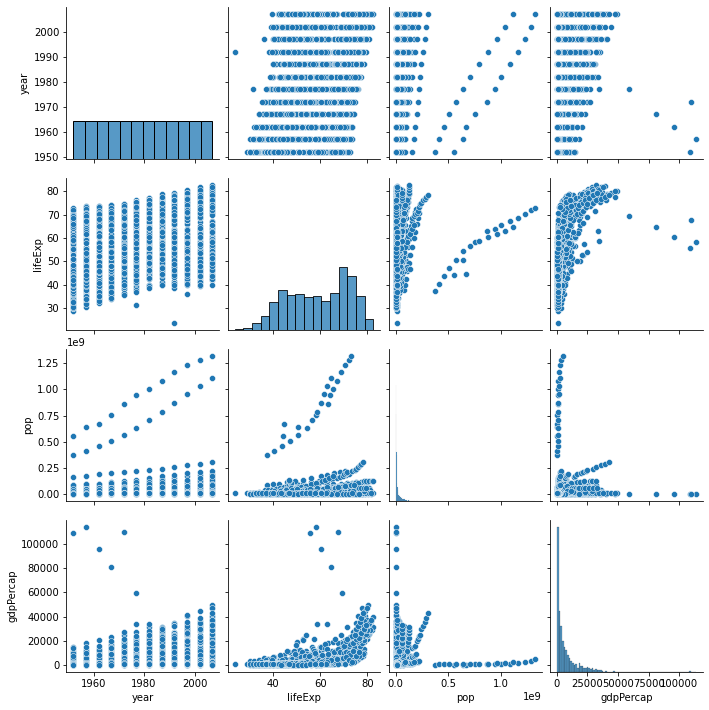

In [12]:
# all continuous variables against each other
sns.pairplot(df_gapminder)

## Single continuous distribution plots

We should start by examining the primary variable of interest, which is life expectancy. Since this is a continuous variable, we use the `distplot()` function. This function will draw a histogram and a kernel density estimator by default, but we can change those defaults through the arguments. Let's start with a default `distplot()`

/Users/jemmanelson/opt/anaconda3/envs/cdc_1/lib/python3.8/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='lifeExp', ylabel='Density'>

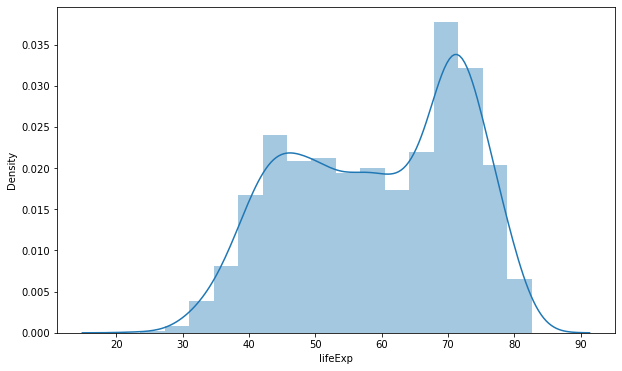

In [13]:
# distribution of life expectancy
sns.distplot(df_gapminder['lifeExp'])

Kernel density estimators can be computationally expensive. Also, they will not work with missing data in a series by default (you would need to use the `.dropna()` method)

/Users/jemmanelson/opt/anaconda3/envs/cdc_1/lib/python3.8/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='lifeExp'>

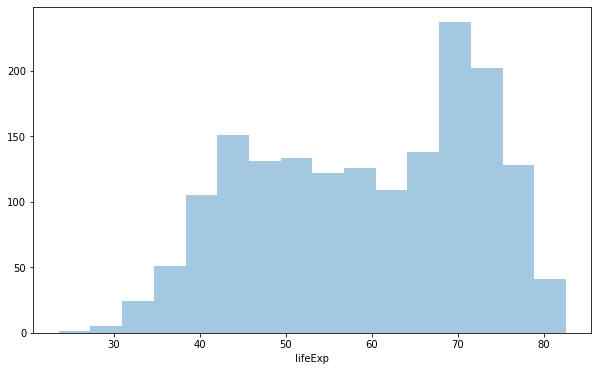

In [14]:
# Turn off the KDE
sns.distplot(df_gapminder['lifeExp'],
             kde=False)

<AxesSubplot:xlabel='lifeExp'>

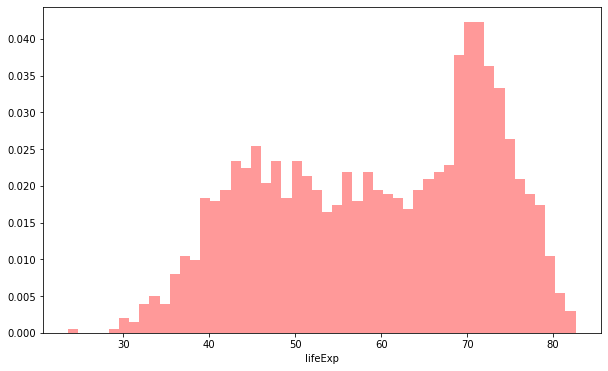

In [15]:
# change the bins, the color, and make the Y axis 'normed' (density)
sns.distplot(df_gapminder['lifeExp'],
             kde=False,
             bins=50,
             color='red',
             norm_hist=True)

What is your initial conclusion about this variable? How would you describe it univariately? What other variables in our dataset might explain this wide variation? We will check that out shortly :) 

## Seaborn themes

Part of the intent of seaborn is to make the default appearance of matplotlib graphs in Python more appealing. Seaborn is simply a wrapper for matplotlib - so all the graphs we are creatign with seaborn are really matplotlib graphs under the hood. 
  
  
If we want to enable these 'prettier'default setting, we first must call the `sns.set()` function.  Notice how the graph changes once we call this below:

In [16]:
# this function resets aesthetics to the seaborn defaults
sns.set()

<AxesSubplot:xlabel='Life Expectancy'>

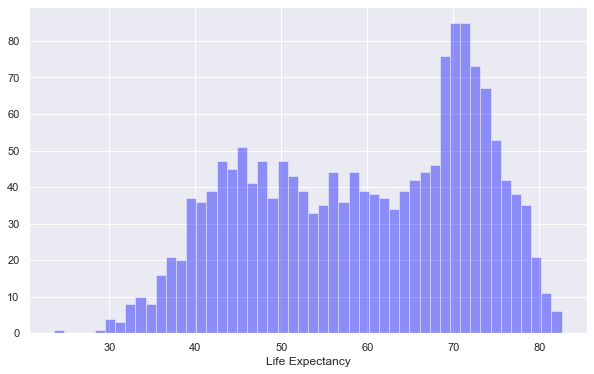

In [17]:
# change the bins, the color
sns.distplot(df_gapminder['lifeExp'],
             kde=False,
             bins=50,
             color='blue',
             axlabel='Life Expectancy')

There are a few different styles available: darkgrid (the default), whitegrid, dark, white, and ticks. 
  
Here is what the whitegrid style looks like (below). You can experiment with the others!

In [18]:
# set to the 'whitegrid' style
sns.set_style("whitegrid")

<AxesSubplot:xlabel='Life Expectancy'>

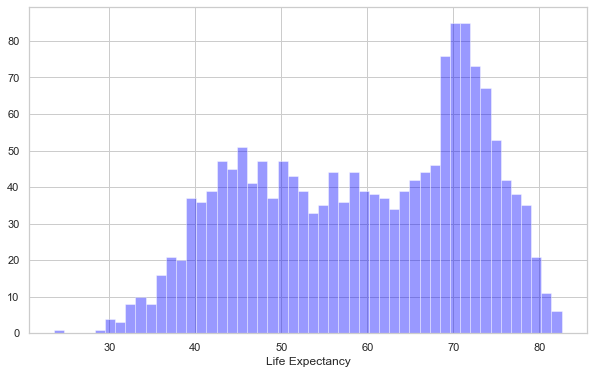

In [19]:
# change the bins, the color
sns.distplot(df_gapminder['lifeExp'],
             kde=False,
             bins=50,
             color='blue',
             axlabel='Life Expectancy')

## Seaborn themes - text size

We may also wish to make the text larger if we are putting this graph in a presentation, or even larger still if we are putting it on a poster. We control that easily with the `sns.set_context()` function. The options include 'paper' (smallest), 'notebook', 'talk', and 'poster' (largest). 

In [20]:
# make text larger, 'talk' size
sns.set_context('talk')

<AxesSubplot:xlabel='Life Expectancy'>

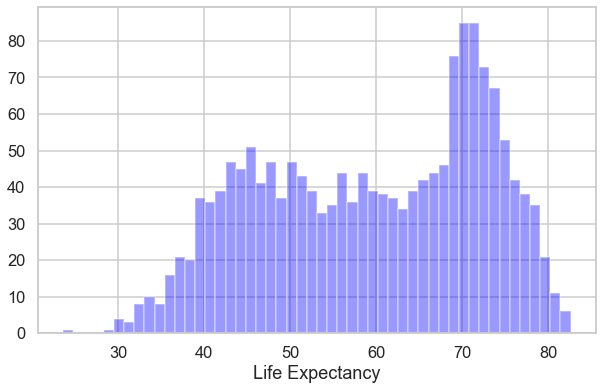

In [21]:
# change the bins, the color, show the increased text sizes
sns.distplot(df_gapminder['lifeExp'],
             kde=False,
             bins=50,
             color='blue',
             axlabel='Life Expectancy')

If we call the `sns.set()` function, everything is reset to default.  

In [22]:
sns.set()

<AxesSubplot:xlabel='Life Expectancy'>

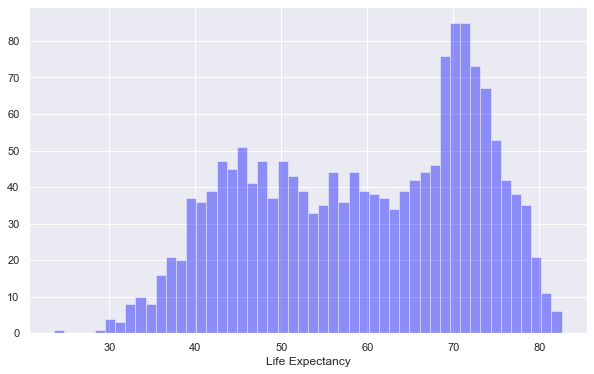

In [23]:
# change the bins, the color, show the increased text sizes
sns.distplot(df_gapminder['lifeExp'],
             kde=False,
             bins=50,
             color='blue',
             axlabel='Life Expectancy')

One question that often comes up at this point is, 'how do I add a title to this graph?'. There is no title parameter for the `sns.distplot()` function (and many other seaborn functions). However, the function returns an 'ax' object. That object has a method called `set_title()`. So we could either save the resulting object and call the method, or simply call it in place. There are a number of other matplotlib methods (like `set_title()`) that you would use the same process to modify. 

Text(0.5, 1.0, 'New Title!')

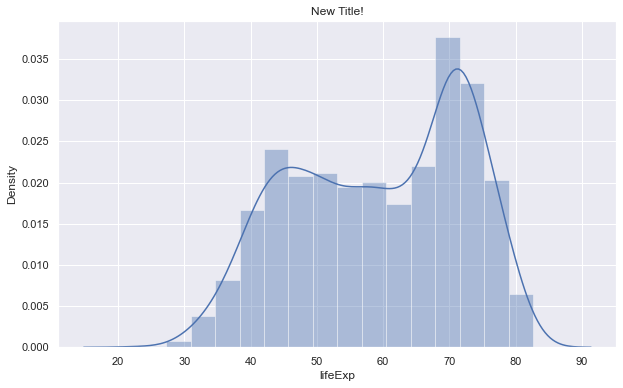

In [24]:
# save return object and call the method
ax = sns.distplot(df_gapminder['lifeExp'])
ax.set_title('New Title!')

/Users/jemmanelson/opt/anaconda3/envs/cdc_1/lib/python3.8/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


Text(0.5, 1.0, 'New Title!')

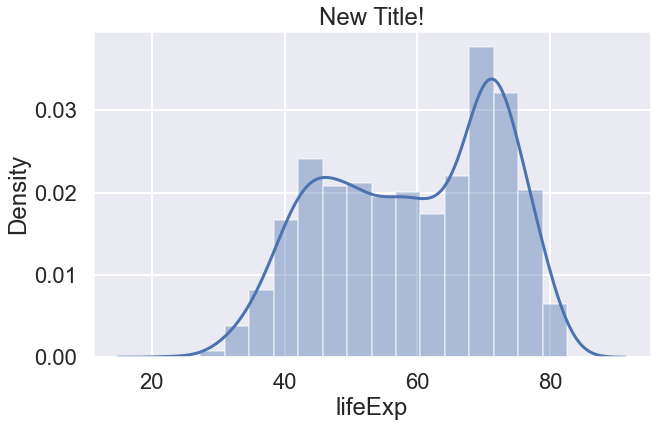

In [25]:
# make text bigger first
sns.set_context('poster')
# apply method directly to plot call
sns.distplot(df_gapminder['lifeExp'])\
    .set_title('New Title!')

## Matplotlib Customizations

Because *Seaborn* is built atop `Matplotlib,` we can further customize it using the Matplotlib library. Matplotlib is the fundamental drawing and charting library of Python. It handles everything from low level "glyph" drawing (arcs, boxes, lines) to animation and color palettes.

Matplotlib is a large and deep library. A full dive into Matplotlib is beyond the scope of this tutorial, but we'll try to give you a feel for basic customizations here. For a next step, check out [Chapter 4 of the Handbook for Data Science.](https://jakevdp.github.io/PythonDataScienceHandbook/04.00-introduction-to-matplotlib.html)

Let's first create our plot. For this example, we'll create a regression plot.


<AxesSubplot:xlabel='gdpPercap', ylabel='lifeExp'>

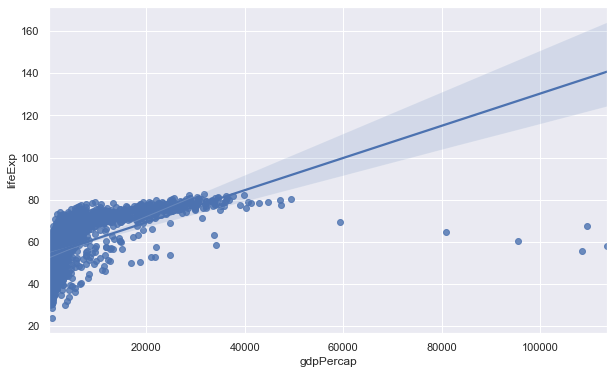

In [26]:
sns.set()
sns.regplot(x='gdpPercap',y='lifeExp',data=df_gapminder)

### Matplotlib Interfaces

There are two different interfaces to `matplotlib`:  

   1. procedural (sequential) interface ("MATLAB"-style)
   2. object-oriented interface
    
This means we can interact with plots in two ways; either (1) sending commands to a plot, drawing it, changing it, annotating it, and then moving on to the next plot, or (2) addressing each plot by a name. In practice, it's often easier to use the second method. In order to do that, we'll save the object, and by convention we call this `ax` for `axes`. 

The first (1) method uses the pyplot interface, and you'll see commands that start with `plt.` The second (2) method uses commands that conventionally start with `ax.` or `fig.` You can mix and match the methods.

Notice when we 'capture' the object with assignment (`ax = `), the matplotlib message doesn't show, but we still draw the graph.

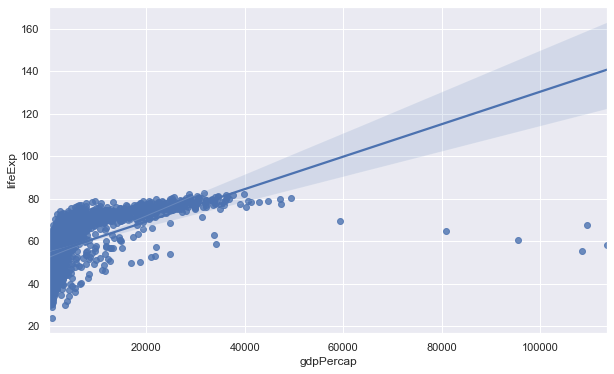

In [27]:
ax = sns.regplot(x='gdpPercap',y='lifeExp',data=df_gapminder)

### Setting Axis Limits

Here, our regression line is going far outside the range of data. Let's limit the bounding box, so we're focused on the data. 

(20.0, 90.0)

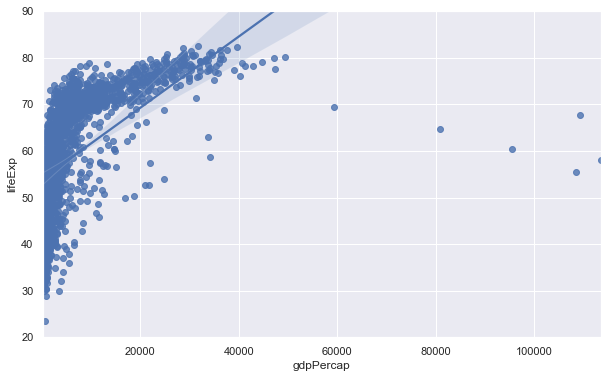

In [28]:
ax = sns.regplot(x='gdpPercap',y='lifeExp',data=df_gapminder)
ax.set_ylim(20,90)

### Adding or Changing x-axis, y-axis, and title

As we saw above, it's easy to change or add axis or label annotation to a plot

(20.0, 90.0)

Text(0.5, 0, 'gdp per capita')

Text(0, 0.5, 'life expectancy')

Text(0.5, 1.0, 'Life Expectancy trend by GDP per Capita')

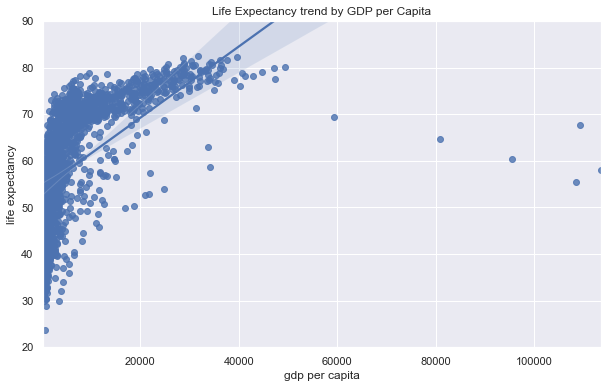

In [29]:
ax = sns.regplot(x='gdpPercap',y='lifeExp',data=df_gapminder)
ax.set_ylim(20,90)
ax.set_xlabel("gdp per capita")
ax.set_ylabel("life expectancy")
ax.set_title("Life Expectancy trend by GDP per Capita")

### Passing Customization through to Matplotlib

This regression plot is composed of a matplotlib scatterplot and a line plot. To address these parts of the chart, we can send keywords *through* seaborn to the underlying matplotlib routines.

For example, if we want to customize the line color from the points color, we can set a line_kws value. We supply a dictionary of the line options we want to change.

(20.0, 90.0)

Text(0.5, 0, 'gdp per capita')

Text(0, 0.5, 'life expectancy')

Text(0.5, 1.0, 'Life Expectancy trend by GDP per Capita')

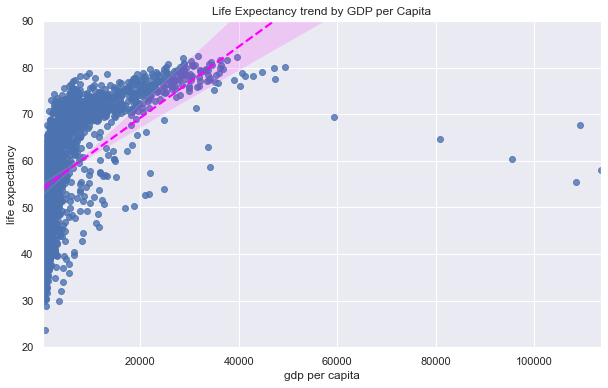

In [30]:
ax = sns.regplot(x='gdpPercap',
                 y='lifeExp',
                 data=df_gapminder,
                 line_kws={"color":"magenta",
                           "linestyle":"--"})
ax.set_ylim(20,90)
ax.set_xlabel("gdp per capita")
ax.set_ylabel("life expectancy")
ax.set_title("Life Expectancy trend by GDP per Capita")


### Adding Annotation

We can easily add annotation as well. 

**Note:** Seaborn's `regplot` does not provide the trend line parameters (slope, intercept, $r^{2}$.) To get those, you'll have to retrieve them from another package, like `statsmodels` or `scipy`.


(20.0, 90.0)

Text(0.5, 0, 'gdp per capita')

Text(0, 0.5, 'life expectancy')

Text(0.5, 1.0, 'Life Expectancy trend by GDP per Capita')

Text(50000, 85, 'This line fits poorly')

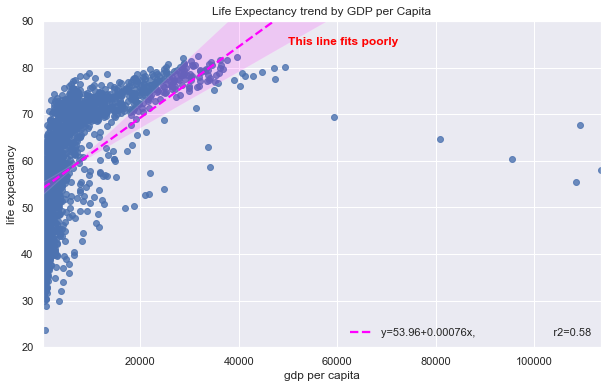

In [31]:
from scipy import stats
slope, intercept, r_value, p_value, std_err = stats.linregress(df_gapminder['gdpPercap'],df_gapminder['lifeExp'])
#
ax = sns.regplot(x='gdpPercap',
                 y='lifeExp',
                 data=df_gapminder,
                 line_kws={"color":"magenta",
                           "linestyle":"--",
                          "label":f"y={np.round(intercept,2)}+{np.round(slope,5)}x,\
                          r2={np.round(r_value,2)}"})
ax.set_ylim(20,90)
ax.set_xlabel("gdp per capita")
ax.set_ylabel("life expectancy")
ax.set_title("Life Expectancy trend by GDP per Capita")
ax.legend(loc='lower right',frameon=False)
ax.text(50000, 85,
        "This line fits poorly",
        horizontalalignment='left',
        size='medium', color='red', weight='semibold')


### Many more customizations

There are many more customizations available. The best way to learn these is to look at the examples provided throughout Seaborns documentation in the Gallery and within the [API documentation.](https://seaborn.pydata.org/generated/seaborn.regplot.html#seaborn.regplot) You can find additional examples at the [Python Graph Gallery](https://python-graph-gallery.com/)

## Plotting by Groups/Loops

What if we want to plot by groups? For example, if we wanted to make regression plots here but grouped on the `Continent` variable?

We can use a Seaborn method here, but we could also think about looping over our data and plotting out a regression plot per level of the Continent variable. In this approach, `matplotlib` by default will *overplot* multiple graphs, and you may not get what you want. 

Instead, call `plt.show()` in the for loop to restart a plot per iteration. (Be sure to import the pyplot module as plt first).

In [32]:
df_gapminder['continent'].unique()

array(['Asia', 'Europe', 'Africa', 'Americas', 'Oceania'], dtype=object)

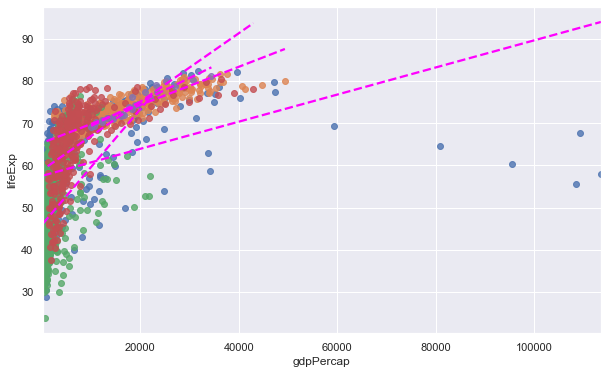

In [33]:
#overplots
for c in df_gapminder['continent'].unique():
    ax = sns.regplot(x='gdpPercap',
                 y='lifeExp',
                 data=df_gapminder.query('continent==@c'),
                 ci=None,
                 line_kws={"color":"magenta",
                           "linestyle":"--"})

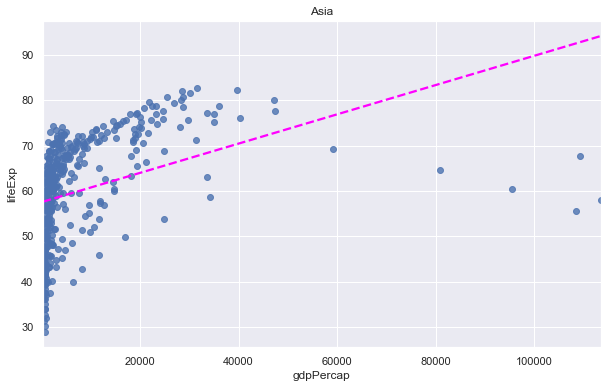

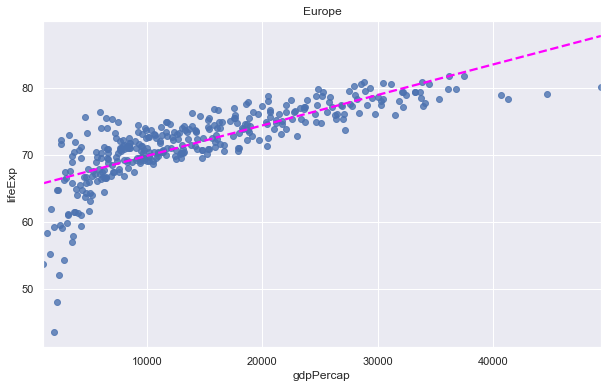

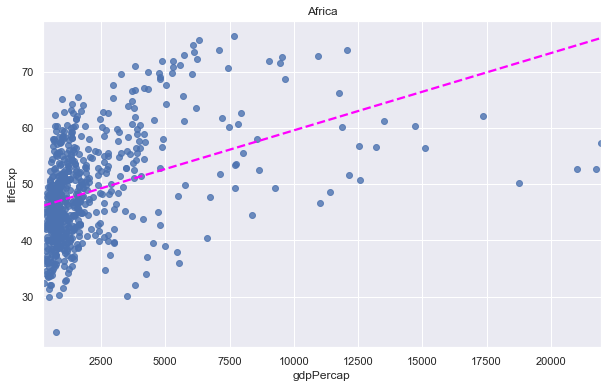

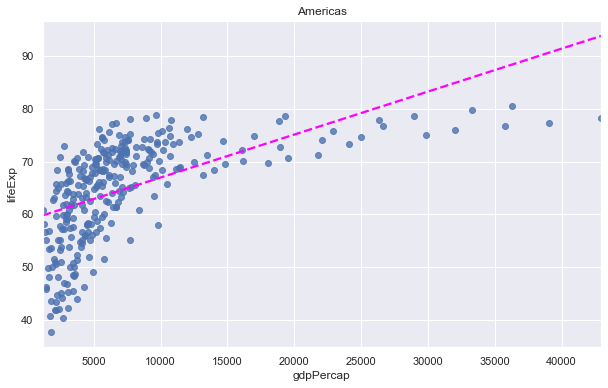

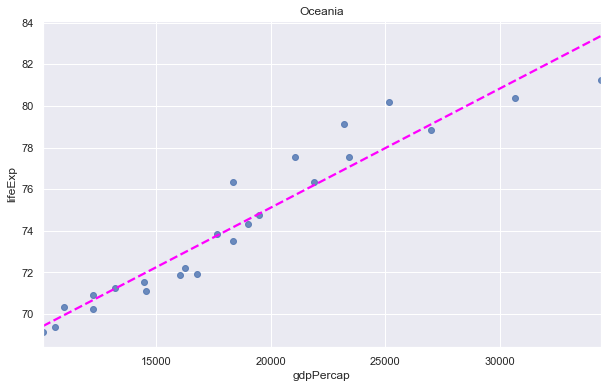

In [34]:
for c in df_gapminder['continent'].unique():
    ax = sns.regplot(x='gdpPercap',
                 y='lifeExp',
                 data=df_gapminder.query('continent==@c'),
                 ci=None,
                 line_kws={"color":"magenta",
                           "linestyle":"--"}).set_title(c)
    plt.show() #kicks off a new plot per loop

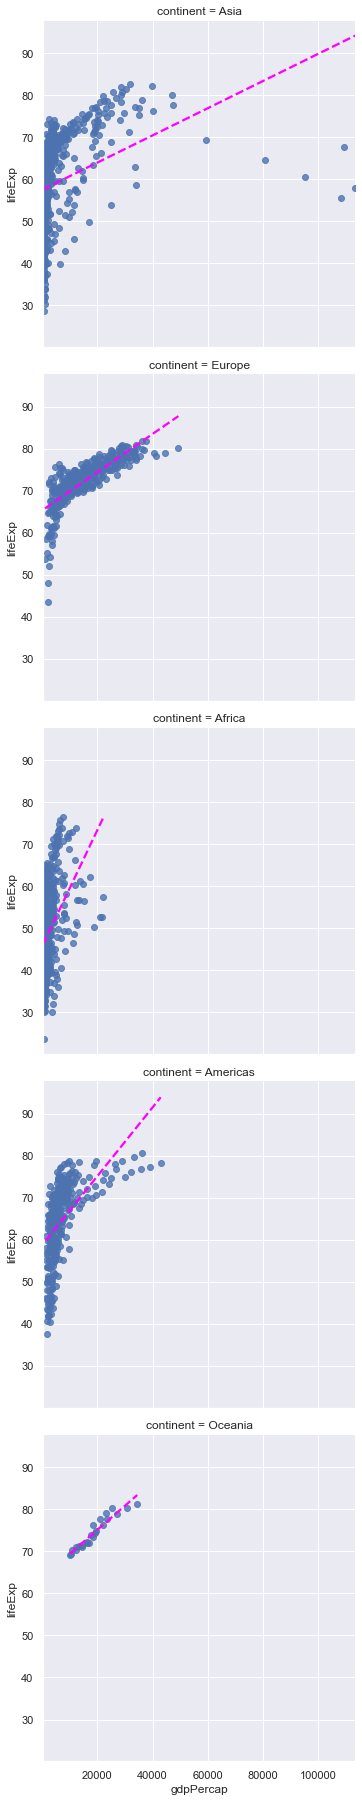

In [35]:
# A seaborn alternative
sns.lmplot(x='gdpPercap',
           y='lifeExp',
           col='continent',
           col_wrap=1,
           data=df_gapminder,
           ci=None,
          line_kws={"color":"magenta",
                           "linestyle":"--"})

## Examining the balance of data across years and continent (discrete plots)

We just saw how to make a basic continuous plot and explored themes and basic colors. But what about discrete plots? I have a few inital questions of this data:  

* How balanced is it across years?
* How balanced is it across continents? 

  
We can answer these questions with discrete count plots `sns.countplot()`. All of the prior points about colors and themes apply here. 

1952    142
1957    142
1962    142
1967    142
1972    142
       ... 
1987    142
1992    142
1997    142
2002    142
2007    142
Name: year, Length: 12, dtype: int64

/Users/jemmanelson/opt/anaconda3/envs/cdc_1/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='year', ylabel='count'>

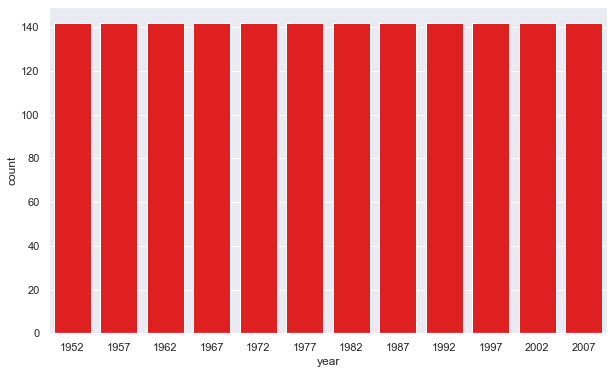

In [36]:
# reset theme
sns.set()
# balance by year
df_gapminder['year'].value_counts() # all years have 142 observations
# plot by year
sns.countplot(df_gapminder['year'],color='red')

This data is precisely balanced across years, which is good. We seem to have balanced panel data here. 

Africa      624
Asia        396
Europe      360
Americas    300
Oceania      24
Name: continent, dtype: int64

/Users/jemmanelson/opt/anaconda3/envs/cdc_1/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='continent', ylabel='count'>

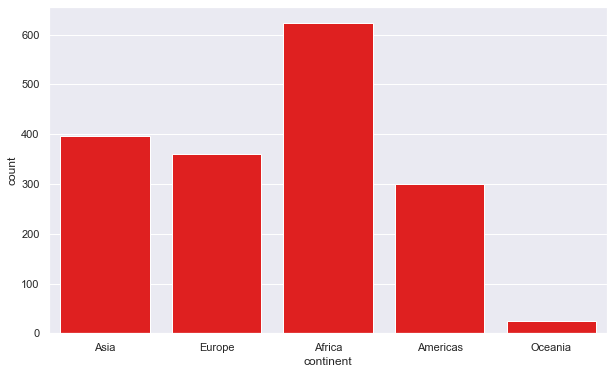

In [37]:
# balance by continent
df_gapminder['continent'].value_counts()
sns.countplot(df_gapminder['continent'],color='red')

This data is not balanced across continent, as expected. The continents all have different numbers of countries. Oceania is the clear outlier. 

## Plotting Multiple Variables: boxplots

So far we have focused on plotting one variable at a time. Now we will examine different techniques in seaborn for plotting multiple variables against each other to understand relationships. 
  
The first question I will try to answer is understanding how life expectancy has changed across year generally in this dataset. If we want to see the full distribution of life expectancy and we consider year to be discrete, a boxplot would be a good choice here. We can see that life expectancy has generally increased over time, but there remains large variability. 

<AxesSubplot:xlabel='year', ylabel='lifeExp'>

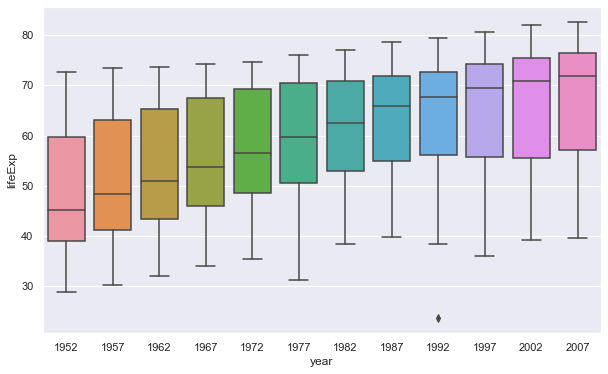

In [38]:
# examine life expectancy across years
sns.boxplot(x='year',
            y='lifeExp',
            data=df_gapminder)

We could also look at life expectancy across continents. Since continent is discrete, we once again use a boxplot. It looks like there is a definite relationship. 

<AxesSubplot:xlabel='continent', ylabel='lifeExp'>

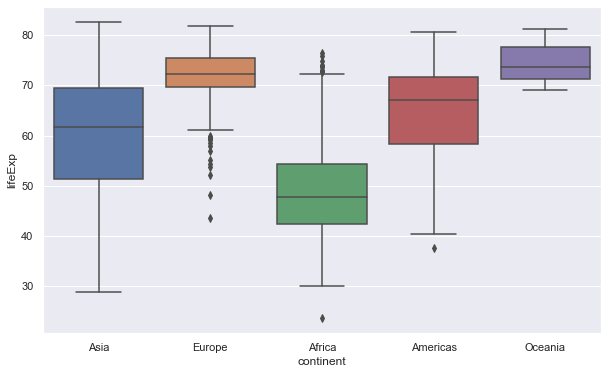

In [39]:
# examine life expectancy across continents
sns.boxplot(x='continent',
            y='lifeExp',
            data=df_gapminder)

But how do we look at both of these discrete variables at the same time? If we have a single continuous variable of interest, with two discrete variable, we can introduct a color grouping for one of the variables. In this case I choose continent as the colors. The resulting plot looks a bit messy since the continents aren't in a good order (relative to life expectancy):

<AxesSubplot:xlabel='year', ylabel='lifeExp'>

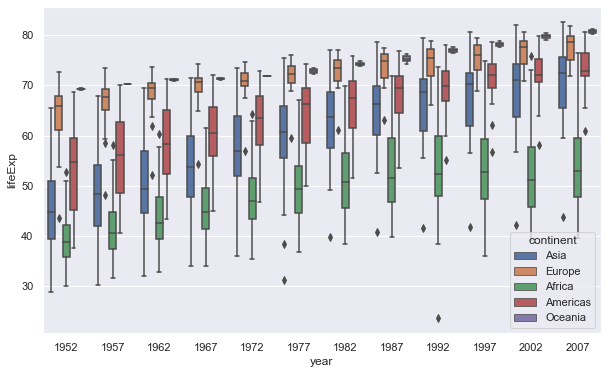

In [40]:
# examine life expectancy across years
# add color linked to continent
sns.boxplot(x='year',
            y='lifeExp',
            hue='continent',
            data=df_gapminder)

We can easily change the order through the `hue_order` argument. I will also remove Oceania from the incoming dataframe since it is so sparse (only two countries). Now we can see that there is relative consistency over time in the life expectancy across countries. 

<AxesSubplot:xlabel='year', ylabel='lifeExp'>

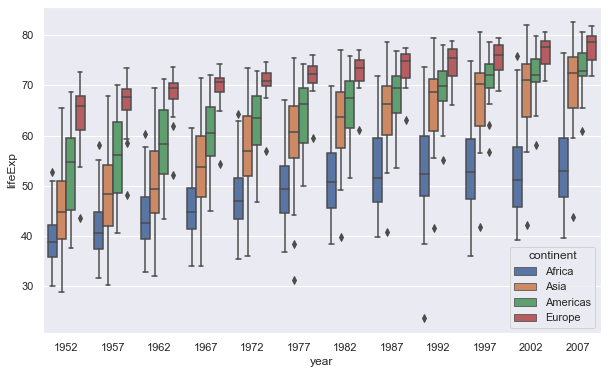

In [41]:
# examine life expectancy across years
# add color linked to continent
# change the hue order
# remove oceania since it is only two countries
sns.boxplot(x='year',
            y='lifeExp',
            hue='continent',
            data=df_gapminder[df_gapminder['continent']!='Oceania'],
            hue_order=['Africa','Asia','Americas','Europe'])

## Lineplots 

The prior boxplots showed a summary of the full distribution. Instead, we may be interested in the **average** life expectancy over time. If so, we can use the `lineplot()` function from seaborn. The simple plot below shows the change in the mean life expectancy across time. It is generally increasing. 

<AxesSubplot:xlabel='year', ylabel='lifeExp'>

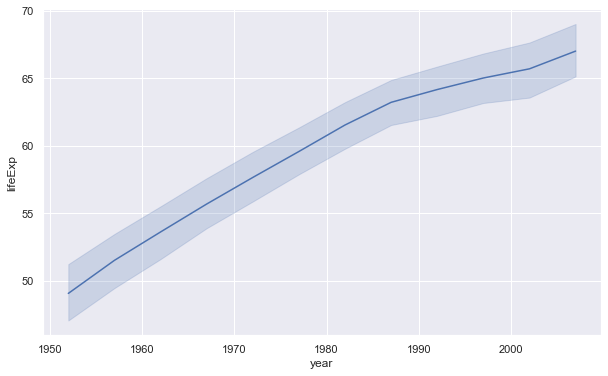

In [42]:
# Plot life expectancy over time - this is the average
sns.lineplot(x='year',
             y='lifeExp',
             data=df_gapminder)

We saw a difference by continent in one of the prior graphs. We can introduce that here as will with either the `hue` or the `style` (or both as shown below).

<AxesSubplot:xlabel='year', ylabel='lifeExp'>

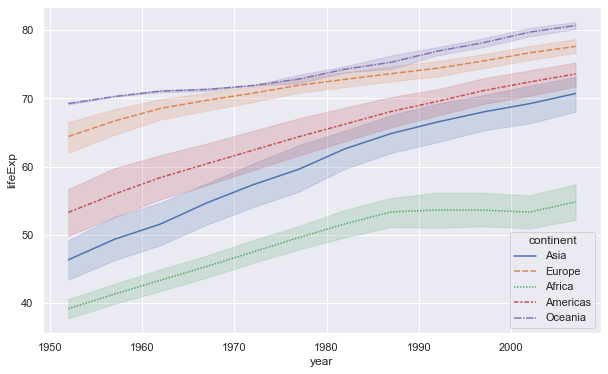

In [43]:
# Plot life expectancy over time - this is the average
sns.lineplot(x='year',
             y='lifeExp',
             data=df_gapminder,
             hue='continent',
             style='continent')

<AxesSubplot:xlabel='year', ylabel='lifeExp'>

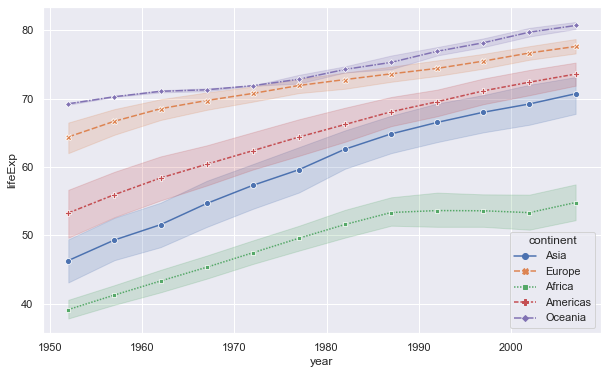

In [44]:
# Plot life expectancy over time
# this is the average with confidence intervals on the mean
sns.lineplot(x='year',
             y='lifeExp',
             data=df_gapminder,
             hue='continent',
             style='continent',
             markers=True) # add markers

Beyond just the average summary, we can use `lineplot` to make spaghetti plots that show the trend of individual countries. Let's start that idea by showing a single country, the United States:

<AxesSubplot:xlabel='year', ylabel='lifeExp'>

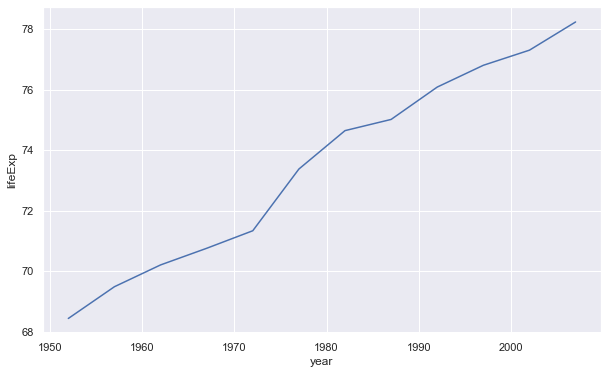

In [45]:
# Plot a single country
sns.lineplot(x='year',
             y='lifeExp',
             data=df_gapminder.query("country == 'United States'"))

If we want this plot but for all countries, we need to tell seaborn what the 'unit' is (country in this case), and also pass in the `estimator=None` argument. I have turned the alpha down so we can see the lines easier. 

<AxesSubplot:xlabel='year', ylabel='lifeExp'>

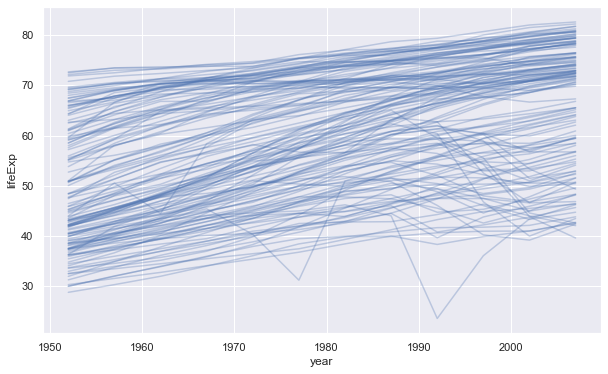

In [46]:
# Plot all countries
sns.lineplot(x='year',
             y='lifeExp',
             units='country',
             data=df_gapminder,
             estimator=None,
             alpha=0.3)

One final modification to this plot - what if we want to see a specific country relative to it's peers? We want to draw the spaghetti plot above for all the countries, then highlight a specific country. To do that, we need to stack two different plots together. We do this by saving the first plot, then using that as an argument into `ax` on the next plot. Here is an example below:

Text(0.5, 1.0, 'United States Life Expectancy (black line)\nVersus Other Countries')

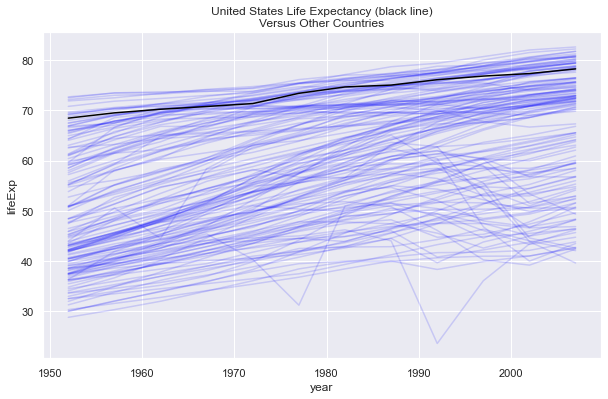

In [47]:
# highlight one country by calling two plots and 'stacking' them:
# Plot all countries and save the object
plt1 = sns.lineplot(x='year',
                    y='lifeExp',
                    units='country',
                    data=df_gapminder.query("country != 'United States'"),
                    estimator=None,
                    color='blue',
                    alpha=0.15)
# pass in the prior plot with the ax= argument
sns.lineplot(x='year',
             y='lifeExp',
             data=df_gapminder.query("country == 'United States'"),
             color='black',
             ax=plt1)\
    .set_title('United States Life Expectancy (black line)\nVersus Other Countries')

And one final modification - what if we wanted to add in the notion of continent to this graph? We could map continent to the `hue`. This graph starts to get very busy though!

Text(0.5, 1.0, 'United States Life Expectancy (black line)\nVersus Other Countries')

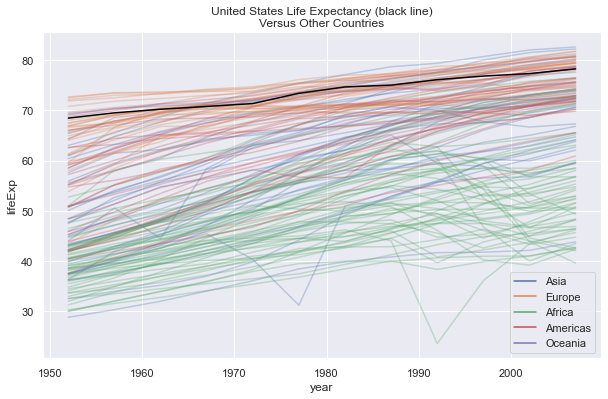

In [48]:
# highlight one country by calling two plots and 'stacking' them:
# Plot all countries and save the object
plt1 = sns.lineplot(x='year',
                    y='lifeExp',
                    units='country',
                    data=df_gapminder.query("country != 'United States'"),
                    estimator=None,
                    hue='continent',
                    alpha=0.3)
# pass in the prior plot with the ax= argument
sns.lineplot(x='year',
             y='lifeExp',
             data=df_gapminder.query("country == 'United States'"),
             color='black',
             ax=plt1)\
    .set_title('United States Life Expectancy (black line)\nVersus Other Countries')

## Conclusion

What conclusions can you draw about the data from the visualization we have seen so far? What other visualizations are you interested in creating that would answer more questions?   
  
  
In this lecture we have gone over the seaborn plotting package. We have covered:
  
* univariate plots
* plotting 2 variables at once
* controlling the themes
* mapping discrete variables to colors and styles
* generating spaghetti plots
  
There is much more to seaborn than this, I encourage you to keep reading about it at the seaborn docs:  
https://seaborn.pydata.org/index.html